# AI-Driven Calibration of Social-Preference Utility Functions via Bilevel Reinforcement Learning  
**Reproducibility / replication notebook (Stage‑1 synthetic validation)**

This notebook implements the *bilevel calibration loop* described in the paper:

1. **Inner loop (policy solving):** given a candidate utility parameter \(\theta=(\alpha,\beta)\), compute proposer/responder behaviour in a one‑shot bargaining environment using:
   - a transparent **REINFORCE** inner solver (*primary method*), and
   - an analytic **best‑response baseline** (*comparison*).
2. **Outer loop (utility calibration):** choose \(\theta\) to minimise a **moment‑matching discrepancy** between simulated behaviour and “observed” behaviour.
3. **Validation:** synthetic parameter‑recovery on **Ultimatum** (fit) with an optional **Dictator** cross‑task predictive check.

## How to run
- Run the notebook **top‑to‑bottom** (“Run all”).
- Outputs (CSV tables + PNG figures) are written to: `outputs/` (set in the imports cell).

## What this produces
- Per‑seed results: `table_on_grid_by_seed.csv`, `table_off_grid_by_seed.csv`
- Seed‑aggregated summaries: `summary_on_grid.csv`, `summary_off_grid.csv`
- Recovery scatter plots (RL vs baseline): `recovery_scatter_*.png`

> Note: All numerical results are generated by simulation; if you change seeds, grid settings, or training steps, the saved outputs will update accordingly.


In [1]:
# If you see import errors, uncomment the pip line and run once:
# !pip -q install numpy pandas matplotlib

import os
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)
print("Ready. Outputs will be saved in:", OUTDIR)

Ready. Outputs will be saved in: outputs


## Notebook map

1. **Imports and output directory**
2. **Model components**
   - Fehr–Schmidt utility \(U_\theta\)
   - Game definitions (Ultimatum, Dictator)
3. **Inner solvers**
   - RL (REINFORCE)
   - Analytic baseline (best responses)
4. **Simulation + moments + discrepancy**
5. **Outer-loop search**
   - Coarse grid
   - Local refinement
6. **Run configuration and experiment suite**
7. **Tables and plots written to `outputs_draft5/`**


In [ ]:
# -----------------------------
# Utility: Fehr–Schmidt (1999)
# -----------------------------

def fehr_schmidt_utility(x_self: np.ndarray, x_other: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    """u_i = x_i - alpha * max(x_j - x_i, 0) - beta * max(x_i - x_j, 0)"""
    disadv = np.maximum(x_other - x_self, 0.0)
    adv = np.maximum(x_self - x_other, 0.0)
    return x_self - alpha * disadv - beta * adv


@dataclass(frozen=True)
class Theta:
    alpha: float
    beta: float

def softmax(logits: np.ndarray) -> np.ndarray:
    z = logits - np.max(logits)
    e = np.exp(z)
    return e / (np.sum(e) + 1e-12)

def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

In [ ]:
# -----------------------------
# Games (one-shot, discretised offers)
# -----------------------------
# Offer is fraction to responder in [0,1]. Total pie=1.
# Ultimatum: proposer offers; responder accepts/rejects.
# Dictator: proposer offers; acceptance is automatic.

@dataclass
class GameConfig:
    name: str  # "ultimatum" or "dictator"
    n_offer_bins: int = 11

def offers_grid(n_offer_bins: int) -> np.ndarray:
    return np.linspace(0.0, 1.0, n_offer_bins)

def payoffs_from_offer_and_accept(offer: np.ndarray, accept: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    # accept in {0,1}
    x_p = (1.0 - offer) * accept
    x_r = offer * accept
    return x_p, x_r

In [ ]:
# -----------------------------
# Inner solver 1: RL (REINFORCE) — minimal, transparent
# -----------------------------

@dataclass
class InnerTrainConfig:
    n_offer_bins: int = 11
    train_steps: int = 4000
    batch_size: int = 512
    lr: float = 0.05
    baseline_momentum: float = 0.98
    seed: int = 0

def train_policies_reinforce(theta: Theta, game: GameConfig, cfg: InnerTrainConfig) -> Dict[str, np.ndarray]:
    """
    Stateless policies:
      - proposer: categorical over offer bins (logits)
      - responder (ultimatum only): Bernoulli accept prob per offer bin (logits)
    """
    rng = np.random.default_rng(cfg.seed)

    proposer_logits = np.zeros(cfg.n_offer_bins, dtype=np.float64)
    responder_logits = np.zeros(cfg.n_offer_bins, dtype=np.float64)  # unused for dictator, kept for uniformity

    b_p = 0.0
    b_r = 0.0
    offers = offers_grid(cfg.n_offer_bins)

    for _ in range(cfg.train_steps):
        probs_p = softmax(proposer_logits)

        offer_idx = rng.choice(cfg.n_offer_bins, size=cfg.batch_size, p=probs_p)
        offer = offers[offer_idx]

        if game.name == "ultimatum":
            p_acc = sigmoid(responder_logits[offer_idx])
            accept = (rng.random(cfg.batch_size) < p_acc).astype(np.int64)
        elif game.name == "dictator":
            # automatic acceptance
            accept = np.ones(cfg.batch_size, dtype=np.int64)
            p_acc = np.ones(cfg.batch_size, dtype=np.float64)
        else:
            raise ValueError("Unknown game")

        x_p, x_r = payoffs_from_offer_and_accept(offer, accept)

        u_p = fehr_schmidt_utility(x_p, x_r, theta.alpha, theta.beta)
        u_r = fehr_schmidt_utility(x_r, x_p, theta.alpha, theta.beta)

        b_p = cfg.baseline_momentum * b_p + (1.0 - cfg.baseline_momentum) * float(np.mean(u_p))
        b_r = cfg.baseline_momentum * b_r + (1.0 - cfg.baseline_momentum) * float(np.mean(u_r))
        adv_p = u_p - b_p
        adv_r = u_r - b_r

        # proposer REINFORCE for categorical: grad ∝ (onehot - probs) * advantage
        probs_p = softmax(proposer_logits)
        grad_p = np.zeros_like(proposer_logits)
        for k in range(cfg.batch_size):
            a = int(offer_idx[k])
            onehot = np.zeros(cfg.n_offer_bins)
            onehot[a] = 1.0
            grad_p += adv_p[k] * (onehot - probs_p)
        grad_p /= float(cfg.batch_size)
        proposer_logits += cfg.lr * grad_p

        # responder (ultimatum only): Bernoulli logit grad ∝ (a - p) * advantage
        if game.name == "ultimatum":
            grad_r = np.zeros_like(responder_logits)
            for k in range(cfg.batch_size):
                b = int(offer_idx[k])
                grad_r[b] += adv_r[k] * (accept[k] - p_acc[k])
            grad_r /= float(cfg.batch_size)
            responder_logits += cfg.lr * grad_r

    return {"proposer_logits": proposer_logits, "responder_logits": responder_logits, "offers": offers}

In [ ]:
# -----------------------------
# Inner solver 2: Analytic baseline (no RL) — best responses in one-shot games
# -----------------------------
# Responder best response (ultimatum):
#   accept offer iff u_r(accept) >= u_r(reject)=0.
# Proposer best response:
#   choose an offer that is accepted and maximises u_p(accept).
# We encode deterministic best response as extreme logits (for comparability).

def baseline_policies_best_response(theta: Theta, game: GameConfig, n_offer_bins: int) -> Dict[str, np.ndarray]:
    offers = offers_grid(n_offer_bins)

    if game.name == "ultimatum":
        # responder: accept iff u_r >= 0
        # accepting payoffs:
        x_p = 1.0 - offers
        x_r = offers
        u_r = fehr_schmidt_utility(x_r, x_p, theta.alpha, theta.beta)
        accept_mask = (u_r >= 0.0).astype(np.float64)

        # proposer chooses best accepted offer by maximising u_p; if none accepted, any offer yields 0
        u_p_accept = fehr_schmidt_utility(x_p, x_r, theta.alpha, theta.beta)
        u_p_accept = np.where(accept_mask > 0.5, u_p_accept, -1e9)
        best_idx = int(np.argmax(u_p_accept)) if np.any(accept_mask > 0.5) else 0

        proposer_logits = -10.0 * np.ones(n_offer_bins)
        proposer_logits[best_idx] = 10.0

        responder_logits = -10.0 * np.ones(n_offer_bins)
        responder_logits[accept_mask > 0.5] = 10.0

    elif game.name == "dictator":
        # acceptance automatic; proposer maximises u_p over offers
        x_p = 1.0 - offers
        x_r = offers
        u_p = fehr_schmidt_utility(x_p, x_r, theta.alpha, theta.beta)
        best_idx = int(np.argmax(u_p))

        proposer_logits = -10.0 * np.ones(n_offer_bins)
        proposer_logits[best_idx] = 10.0

        responder_logits = 10.0 * np.ones(n_offer_bins)  # unused
    else:
        raise ValueError("Unknown game")

    return {"proposer_logits": proposer_logits, "responder_logits": responder_logits, "offers": offers}

In [ ]:
# -----------------------------
# Simulation + moments
# -----------------------------

@dataclass
class EvalConfig:
    n_offer_bins: int = 11
    n_episodes: int = 20000
    seed: int = 123

def simulate_moments(policy: Dict[str, np.ndarray], game: GameConfig, cfg: EvalConfig) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(cfg.seed)
    offers = policy["offers"]
    proposer_logits = policy["proposer_logits"]
    responder_logits = policy["responder_logits"]

    probs_p = softmax(proposer_logits)
    offer_idx = rng.choice(cfg.n_offer_bins, size=cfg.n_episodes, p=probs_p)
    offer = offers[offer_idx]

    if game.name == "ultimatum":
        p_acc = sigmoid(responder_logits[offer_idx])
        accept = (rng.random(cfg.n_episodes) < p_acc).astype(np.int64)
        accept_rate = float(np.mean(accept))
        acc_by_bin = sigmoid(responder_logits).astype(np.float64)
    elif game.name == "dictator":
        accept = np.ones(cfg.n_episodes, dtype=np.int64)
        accept_rate = 1.0
        acc_by_bin = None  # not used
    else:
        raise ValueError("Unknown game")

    mean_offer = float(np.mean(offer))
    offer_prob = probs_p.astype(np.float64)

    out = {"mean_offer": mean_offer, "offer_prob": offer_prob, "offers": offers, "accept_rate": accept_rate}
    if game.name == "ultimatum":
        out["acc_by_bin"] = acc_by_bin
    return out


def moment_distance(m_sim: Dict[str, np.ndarray], m_obs: Dict[str, np.ndarray], game: GameConfig,
                    w: Dict[str, float]) -> float:
    # game-aware distance: dictator has no acceptance curve
    loss = 0.0
    loss += w.get("mean_offer", 1.0) * float((m_sim["mean_offer"] - m_obs["mean_offer"]) ** 2)
    loss += w.get("offer_prob", 1.0) * float(np.mean((m_sim["offer_prob"] - m_obs["offer_prob"]) ** 2))
    if game.name == "ultimatum":
        loss += w.get("accept_rate", 1.0) * float((m_sim["accept_rate"] - m_obs["accept_rate"]) ** 2)
        loss += w.get("acc_by_bin", 1.0) * float(np.mean((m_sim["acc_by_bin"] - m_obs["acc_by_bin"]) ** 2))
    return float(loss)

In [ ]:
# -----------------------------
# Caching: inner-solver evaluation cache
# -----------------------------

def theta_key(theta: Theta) -> Tuple[float, float]:
    # stable keys for caching (avoid float rep issues)
    return (float(np.round(theta.alpha, 6)), float(np.round(theta.beta, 6)))

class EvalCache:
    def __init__(self):
        self._store = {}  # (solver, game, seed, theta_key, train_steps) -> moments dict

    def get(self, solver: str, game: str, seed: int, theta: Theta, train_steps: int) -> Optional[Dict]:
        return self._store.get((solver, game, seed, theta_key(theta), int(train_steps)))

    def set(self, solver: str, game: str, seed: int, theta: Theta, train_steps: int, moments: Dict) -> None:
        self._store[(solver, game, seed, theta_key(theta), int(train_steps))] = moments

CACHE = EvalCache()

In [ ]:
# -----------------------------
# Evaluate theta under an inner solver (RL or baseline), returning moments for a given game
# -----------------------------

def eval_theta_moments(
    theta: Theta,
    game: GameConfig,
    solver: str,
    seed: int,
    inner_cfg: InnerTrainConfig,
    eval_cfg: EvalConfig,
) -> Dict:
    cached = CACHE.get(solver, game.name, seed, theta, inner_cfg.train_steps)
    if cached is not None:
        return cached

    if solver == "rl":
        inner_cfg2 = InnerTrainConfig(**{**inner_cfg.__dict__, "seed": seed})
        pol = train_policies_reinforce(theta, game, inner_cfg2)
    elif solver == "baseline":
        pol = baseline_policies_best_response(theta, game, n_offer_bins=inner_cfg.n_offer_bins)
    else:
        raise ValueError("solver must be 'rl' or 'baseline'")

    ev_cfg2 = EvalConfig(**{**eval_cfg.__dict__, "seed": seed + 123})
    m = simulate_moments(pol, game, ev_cfg2)
    CACHE.set(solver, game.name, seed, theta, inner_cfg.train_steps, m)
    return m

In [ ]:
# -----------------------------
# Outer loop: Stage 1 coarse grid + Stage 2 local refinement
# -----------------------------

@dataclass
class SearchConfig:
    # Stage 1 coarse candidates
    alpha_grid: List[float]
    beta_grid: List[float]
    # Stage 2 refinement
    refine_local: bool = True
    local_radius_alpha: float = 0.5
    local_radius_beta: float = 0.25
    local_step_alpha: float = 0.1
    local_step_beta: float = 0.1

def build_theta_grid(alpha_vals: List[float], beta_vals: List[float]) -> List[Theta]:
    return [Theta(a,b) for a in alpha_vals for b in beta_vals]

def build_local_grid(center: Theta, sc: SearchConfig) -> List[Theta]:
    a0, b0 = center.alpha, center.beta
    a_vals = np.arange(a0 - sc.local_radius_alpha, a0 + sc.local_radius_alpha + 1e-9, sc.local_step_alpha)
    b_vals = np.arange(b0 - sc.local_radius_beta,  b0 + sc.local_radius_beta  + 1e-9, sc.local_step_beta)
    # enforce non-negativity for alpha,beta (consistent with usual FS constraints)
    a_vals = [float(a) for a in a_vals if a >= 0.0]
    b_vals = [float(b) for b in b_vals if b >= 0.0]
    return build_theta_grid(a_vals, b_vals)

def fit_theta_coarse_to_refine(
    obs_moments_by_game: Dict[str, Dict],
    games_for_fit: List[GameConfig],
    solver: str,
    seed: int,
    inner_cfg: InnerTrainConfig,
    eval_cfg: EvalConfig,
    weights: Dict[str, float],
    sc: SearchConfig,
) -> Dict:
    # Stage 1 coarse
    coarse_candidates = build_theta_grid(sc.alpha_grid, sc.beta_grid)
    best_theta_1, best_L1 = None, float("inf")

    for th in coarse_candidates:
        L = 0.0
        for g in games_for_fit:
            m_sim = eval_theta_moments(th, g, solver, seed, inner_cfg, eval_cfg)
            L += moment_distance(m_sim, obs_moments_by_game[g.name], g, weights)
        if L < best_L1:
            best_L1, best_theta_1 = L, th

    # Stage 2 local refinement
    best_theta_2, best_L2 = best_theta_1, best_L1
    if sc.refine_local:
        local_candidates = build_local_grid(best_theta_1, sc)
        for th in local_candidates:
            L = 0.0
            for g in games_for_fit:
                m_sim = eval_theta_moments(th, g, solver, seed, inner_cfg, eval_cfg)
                L += moment_distance(m_sim, obs_moments_by_game[g.name], g, weights)
            if L < best_L2:
                best_L2, best_theta_2 = L, th

    return {
        "theta_hat_stage1": best_theta_1,
        "loss_stage1": best_L1,
        "theta_hat_refined": best_theta_2,
        "loss_refined": best_L2,
    }

In [ ]:
# -----------------------------
# Plotting helpers
# -----------------------------

def plot_recovery_scatter(df: pd.DataFrame, out_png: str, title: str) -> None:
    fig = plt.figure(figsize=(9,4))
    ax1 = fig.add_subplot(1,2,1)
    ax2 = fig.add_subplot(1,2,2)

    ax1.scatter(df["alpha_true"], df["alpha_hat"])
    lo, hi = float(df["alpha_true"].min()), float(df["alpha_true"].max())
    ax1.plot([lo, hi], [lo, hi])
    ax1.set_title("Alpha recovery")
    ax1.set_xlabel("alpha_true")
    ax1.set_ylabel("alpha_hat")

    ax2.scatter(df["beta_true"], df["beta_hat"])
    lo, hi = float(df["beta_true"].min()), float(df["beta_true"].max())
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title("Beta recovery")
    ax2.set_xlabel("beta_true")
    ax2.set_ylabel("beta_hat")

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.close(fig)

def mean_sd(x: pd.Series) -> Tuple[float,float]:
    return float(x.mean()), float(x.std(ddof=1)) if len(x) > 1 else (float(x.mean()), 0.0)

In [ ]:
# =============================
# RUN CONFIG (edit here)
# =============================

# Seeds for robustness
SEEDS = [0, 1, 2, 3, 4]  # edit if you want fewer/more

# Games
G_ULT = GameConfig(name="ultimatum", n_offer_bins=11)
G_DIC = GameConfig(name="dictator", n_offer_bins=11)

# Fit mode:
#   JOINT_FIT=True  -> fit theta to BOTH ultimatum + dictator moments
#   JOINT_FIT=False -> fit theta on ultimatum only, then evaluate dictator prediction error
JOINT_FIT = False

# True theta lists
THETA_TRUE_ON_GRID = [
    Theta(0.0, 0.0),
    Theta(0.5, 0.25),
    Theta(1.0, 0.5),
    Theta(1.5, 0.75),
]

THETA_TRUE_OFF_GRID = [
    Theta(0.75, 0.35),
    Theta(1.25, 0.60),
    Theta(0.30, 0.70),
    Theta(1.80, 0.40),
]

# Inner training/eval configs (RL uses these; baseline ignores train_steps but cache key includes it)
INNER_CFG = InnerTrainConfig(n_offer_bins=11, train_steps=4000, batch_size=512, lr=0.05, seed=0)
EVAL_CFG  = EvalConfig(n_offer_bins=11, n_episodes=20000, seed=123)

# Outer search config: coarse grid + local refine
SEARCH_CFG = SearchConfig(
    alpha_grid=[0.0, 0.5, 1.0, 1.5, 2.0],
    beta_grid=[0.0, 0.25, 0.5, 0.75, 1.0],
    refine_local=True,
    local_radius_alpha=0.5,
    local_radius_beta=0.25,
    local_step_alpha=0.1,
    local_step_beta=0.1,
)

# Moment weights
WEIGHTS = {"mean_offer": 1.0, "offer_prob": 1.0, "accept_rate": 1.0, "acc_by_bin": 1.0}

# Solvers to compare
SOLVERS = ["rl", "baseline"]

print("Config loaded.")
print("JOINT_FIT =", JOINT_FIT)
print("SEEDS =", SEEDS)
print("INNER_CFG.train_steps =", INNER_CFG.train_steps)
print("Refine local =", SEARCH_CFG.refine_local, "step alpha/beta =", SEARCH_CFG.local_step_alpha, SEARCH_CFG.local_step_beta)

Config loaded.
JOINT_FIT = False
SEEDS = [0, 1, 2, 3, 4]
INNER_CFG.train_steps = 4000
Refine local = True step alpha/beta = 0.1 0.1


In [ ]:
# -----------------------------
# Helper: generate observed moments for a theta_true (using a chosen 'truth' solver)
# -----------------------------
# For synthetic validation, we treat the "true world" as the RL inner solver (transparent policy-gradient)
# because it matches the method's intended use. You can change TRUE_SOLVER to "baseline" if desired.

TRUE_SOLVER = "rl"

def observed_moments(theta_true: Theta, seed: int) -> Dict[str, Dict]:
    obs = {}
    for g in [G_ULT, G_DIC]:
        obs[g.name] = eval_theta_moments(theta_true, g, TRUE_SOLVER, seed, INNER_CFG, EVAL_CFG)
    return obs

In [ ]:
# -----------------------------
# Main runner: on-grid + off-grid, per solver, per seed
# -----------------------------

def run_suite(theta_list: List[Theta], tag: str) -> Dict[str, pd.DataFrame]:
    rows_all = []

    for solver in SOLVERS:
        for seed in SEEDS:
            for theta_true in theta_list:
                obs = observed_moments(theta_true, seed=seed)

                # which games are used in fitting?
                games_for_fit = [G_ULT, G_DIC] if JOINT_FIT else [G_ULT]

                fit = fit_theta_coarse_to_refine(
                    obs_moments_by_game=obs,
                    games_for_fit=games_for_fit,
                    solver=solver,
                    seed=seed,
                    inner_cfg=INNER_CFG,
                    eval_cfg=EVAL_CFG,
                    weights=WEIGHTS,
                    sc=SEARCH_CFG,
                )

                th1 = fit["theta_hat_stage1"]
                th2 = fit["theta_hat_refined"]

                # Evaluate fitted theta on both games (for reporting)
                m_hat_ult = eval_theta_moments(th2, G_ULT, solver, seed, INNER_CFG, EVAL_CFG)
                m_hat_dic = eval_theta_moments(th2, G_DIC, solver, seed, INNER_CFG, EVAL_CFG)

                # distances on each game (even if not fitted)
                L_ult = moment_distance(m_hat_ult, obs["ultimatum"], G_ULT, WEIGHTS)
                L_dic = moment_distance(m_hat_dic, obs["dictator"], G_DIC, WEIGHTS)
                L_joint = L_ult + L_dic

                rows_all.append({
                    "tag": tag,
                    "solver": solver,
                    "seed": seed,
                    "alpha_true": theta_true.alpha,
                    "beta_true": theta_true.beta,

                    "alpha_hat_stage1": th1.alpha,
                    "beta_hat_stage1": th1.beta,
                    "loss_stage1_fitobj": fit["loss_stage1"],

                    "alpha_hat": th2.alpha,
                    "beta_hat": th2.beta,
                    "loss_refined_fitobj": fit["loss_refined"],

                    "loss_ultimatum": L_ult,
                    "loss_dictator": L_dic,
                    "loss_joint": L_joint,

                    "mean_offer_true_ult": obs["ultimatum"]["mean_offer"],
                    "mean_offer_hat_ult": m_hat_ult["mean_offer"],
                    "accept_rate_true": obs["ultimatum"]["accept_rate"],
                    "accept_rate_hat": m_hat_ult["accept_rate"],

                    "mean_offer_true_dic": obs["dictator"]["mean_offer"],
                    "mean_offer_hat_dic": m_hat_dic["mean_offer"],
                })

    df = pd.DataFrame(rows_all)

    # Save by-seed detailed table
    path = os.path.join(OUTDIR, f"table_{tag}_by_seed.csv")
    df.to_csv(path, index=False)
    print("Saved:", path)

    return {tag: df}

# Run
dfs = {}
dfs.update(run_suite(THETA_TRUE_ON_GRID, "on_grid"))
dfs.update(run_suite(THETA_TRUE_OFF_GRID, "off_grid"))

dfs.keys()

Saved: outputs_draft5/table_on_grid_by_seed.csv
Saved: outputs_draft5/table_off_grid_by_seed.csv


dict_keys(['on_grid', 'off_grid'])

In [ ]:
# -----------------------------
# Summaries (mean ± sd across seeds) for each solver
# -----------------------------

def summarise(df: pd.DataFrame, tag: str) -> pd.DataFrame:
    grp_cols = ["solver","alpha_true","beta_true"]
    rows = []
    for (solver,a,b), g in df[df["tag"]==tag].groupby(grp_cols):
        rows.append({
            "solver": solver,
            "alpha_true": a,
            "beta_true": b,
            "alpha_hat_mean": float(g["alpha_hat"].mean()),
            "alpha_hat_sd": float(g["alpha_hat"].std(ddof=1)) if len(g)>1 else 0.0,
            "beta_hat_mean": float(g["beta_hat"].mean()),
            "beta_hat_sd": float(g["beta_hat"].std(ddof=1)) if len(g)>1 else 0.0,
            "loss_ult_mean": float(g["loss_ultimatum"].mean()),
            "loss_ult_sd": float(g["loss_ultimatum"].std(ddof=1)) if len(g)>1 else 0.0,
            "loss_dic_mean": float(g["loss_dictator"].mean()),
            "loss_dic_sd": float(g["loss_dictator"].std(ddof=1)) if len(g)>1 else 0.0,
            "loss_joint_mean": float(g["loss_joint"].mean()),
            "loss_joint_sd": float(g["loss_joint"].std(ddof=1)) if len(g)>1 else 0.0,
        })
    out = pd.DataFrame(rows).sort_values(["solver","alpha_true","beta_true"]).reset_index(drop=True)
    return out

sum_on  = summarise(dfs["on_grid"], "on_grid")
sum_off = summarise(dfs["off_grid"], "off_grid")

sum_on_path = os.path.join(OUTDIR, "summary_on_grid.csv")
sum_off_path = os.path.join(OUTDIR, "summary_off_grid.csv")
sum_on.to_csv(sum_on_path, index=False)
sum_off.to_csv(sum_off_path, index=False)

print("Saved:", sum_on_path)
print("Saved:", sum_off_path)

sum_on.head(10), sum_off.head(10)

Saved: outputs_draft5/summary_on_grid.csv
Saved: outputs_draft5/summary_off_grid.csv


(     solver  alpha_true  beta_true  alpha_hat_mean  alpha_hat_sd  \
 0  baseline         0.0       0.00             0.1           0.0   
 1  baseline         0.5       0.25             1.0           0.0   
 2  baseline         1.0       0.50             1.0           0.0   
 3  baseline         1.5       0.75             1.0           0.0   
 4        rl         0.0       0.00             0.0           0.0   
 5        rl         0.5       0.25             0.5           0.0   
 6        rl         1.0       0.50             1.0           0.0   
 7        rl         1.5       0.75             1.5           0.0   
 
    beta_hat_mean  beta_hat_sd  loss_ult_mean  loss_ult_sd  loss_dic_mean  \
 0           0.05          0.0       0.142671     0.004611       0.000071   
 1           0.00          0.0       0.121287     0.002896       0.000280   
 2           0.75          0.0       0.108067     0.000254       0.133835   
 3           0.75          0.0       0.124649     0.000205       0.00

In [ ]:
# -----------------------------
# Plots: recovery scatter (refined theta) for RL vs baseline
# -----------------------------

def make_scatter(df: pd.DataFrame, tag: str, solver: str, out_png: str):
    sub = df[(df["tag"]==tag) & (df["solver"]==solver)][["alpha_true","beta_true","alpha_hat","beta_hat"]].copy()
    plot_recovery_scatter(sub, out_png, title=f"{solver.upper()} — {tag} — refined estimates")

# By-seed dataframes contain repeated points across seeds; use summary means for cleaner scatter
def make_scatter_from_summary(summary_df: pd.DataFrame, tag: str, solver: str, out_png: str):
    sub = summary_df[summary_df["solver"]==solver][["alpha_true","beta_true","alpha_hat_mean","beta_hat_mean"]].copy()
    sub = sub.rename(columns={"alpha_hat_mean":"alpha_hat","beta_hat_mean":"beta_hat"})
    plot_recovery_scatter(sub, out_png, title=f"{solver.upper()} — {tag} — mean refined estimates")

png1 = os.path.join(OUTDIR, "recovery_scatter_on_grid_rl.png")
png2 = os.path.join(OUTDIR, "recovery_scatter_off_grid_rl.png")
png3 = os.path.join(OUTDIR, "recovery_scatter_on_grid_baseline.png")
png4 = os.path.join(OUTDIR, "recovery_scatter_off_grid_baseline.png")

make_scatter_from_summary(sum_on, "on_grid", "rl", png1)
make_scatter_from_summary(sum_off, "off_grid", "rl", png2)
make_scatter_from_summary(sum_on, "on_grid", "baseline", png3)
make_scatter_from_summary(sum_off, "off_grid", "baseline", png4)

print("Saved:")
print(png1)
print(png2)
print(png3)
print(png4)

Saved:
outputs_draft5/recovery_scatter_on_grid_rl.png
outputs_draft5/recovery_scatter_off_grid_rl.png
outputs_draft5/recovery_scatter_on_grid_baseline.png
outputs_draft5/recovery_scatter_off_grid_baseline.png


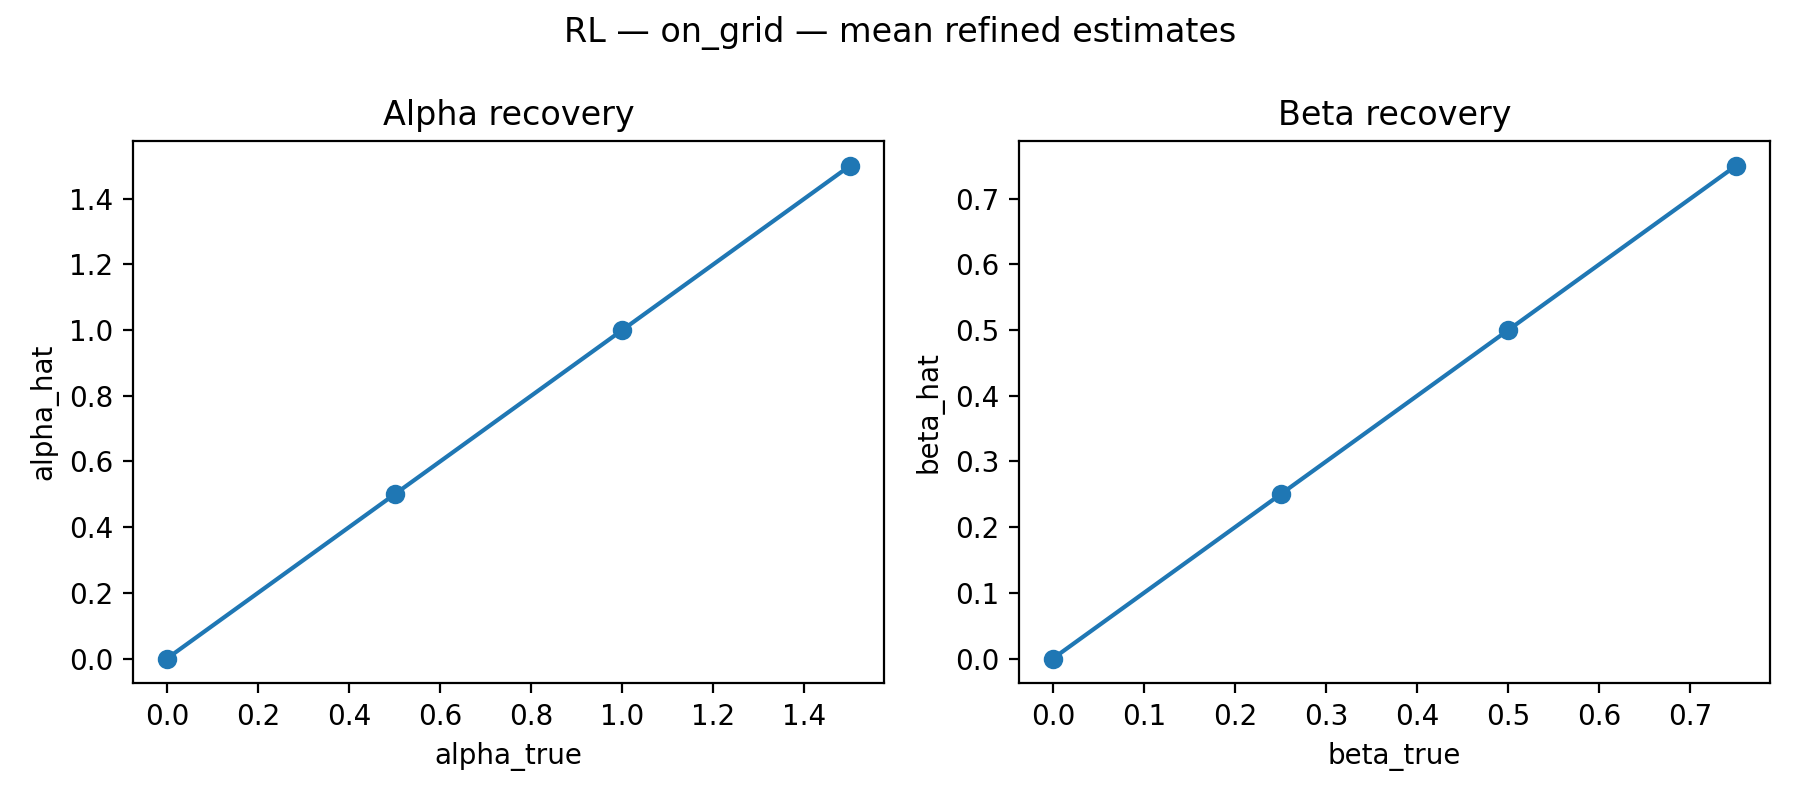

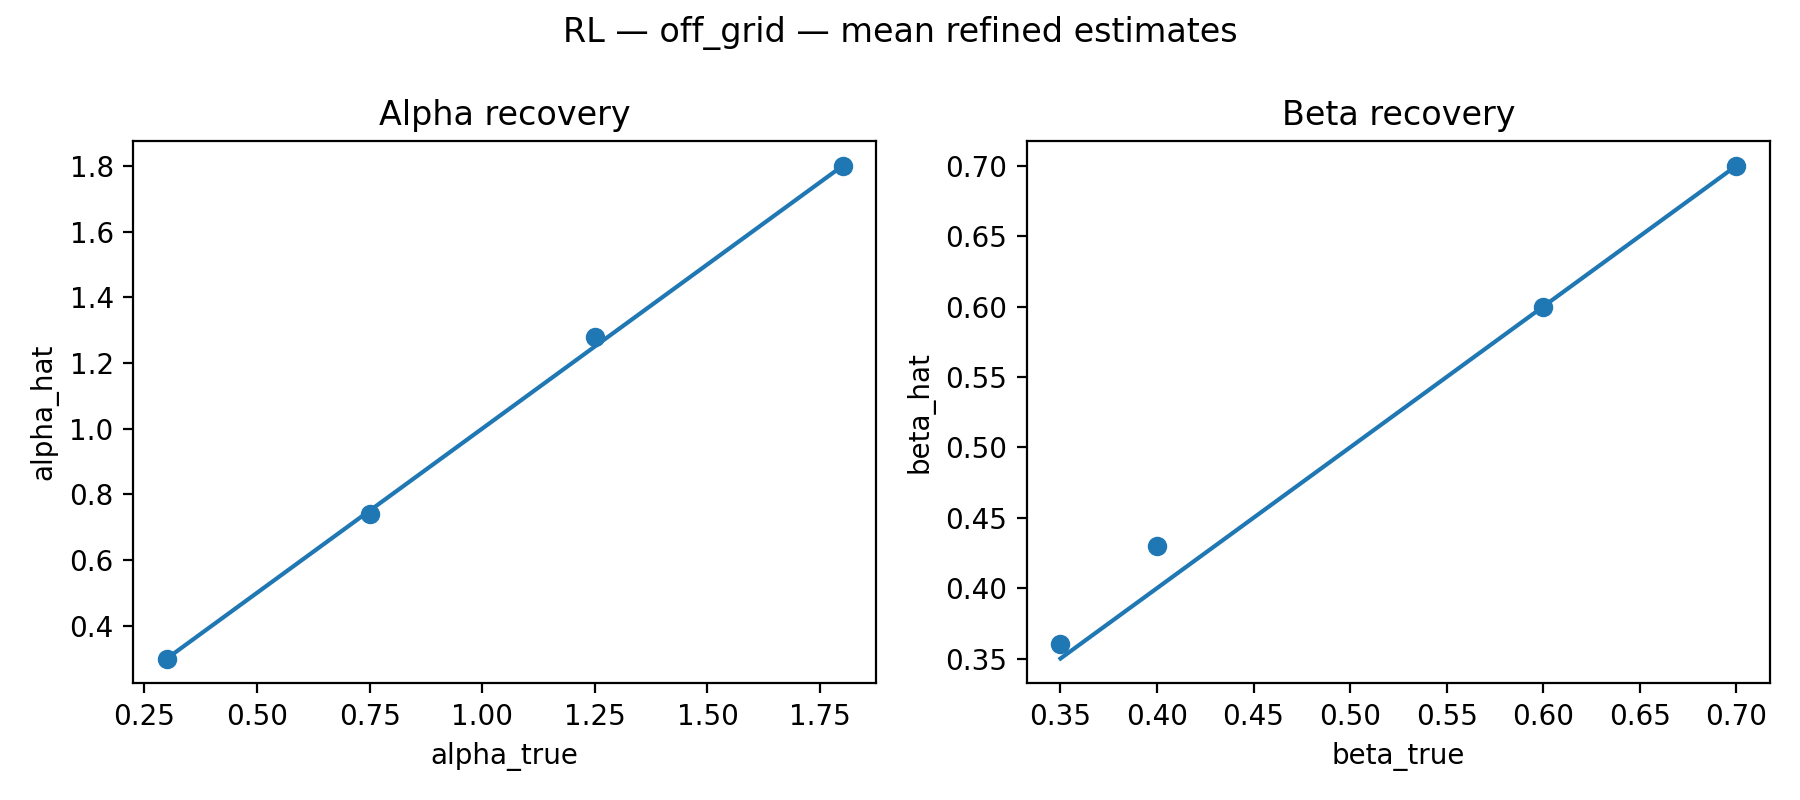

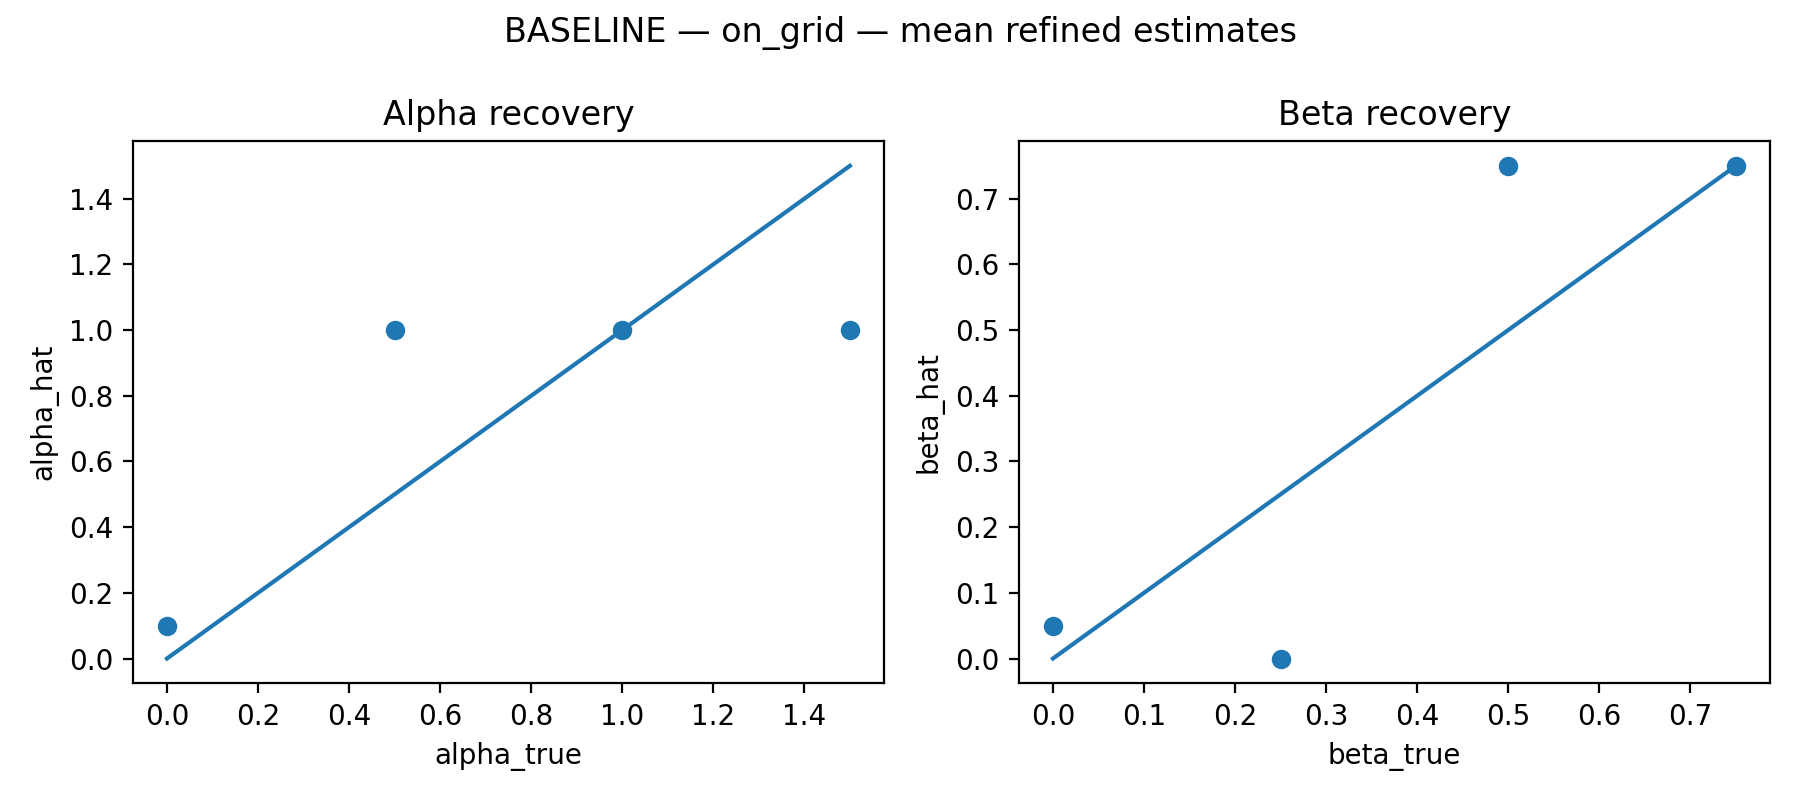

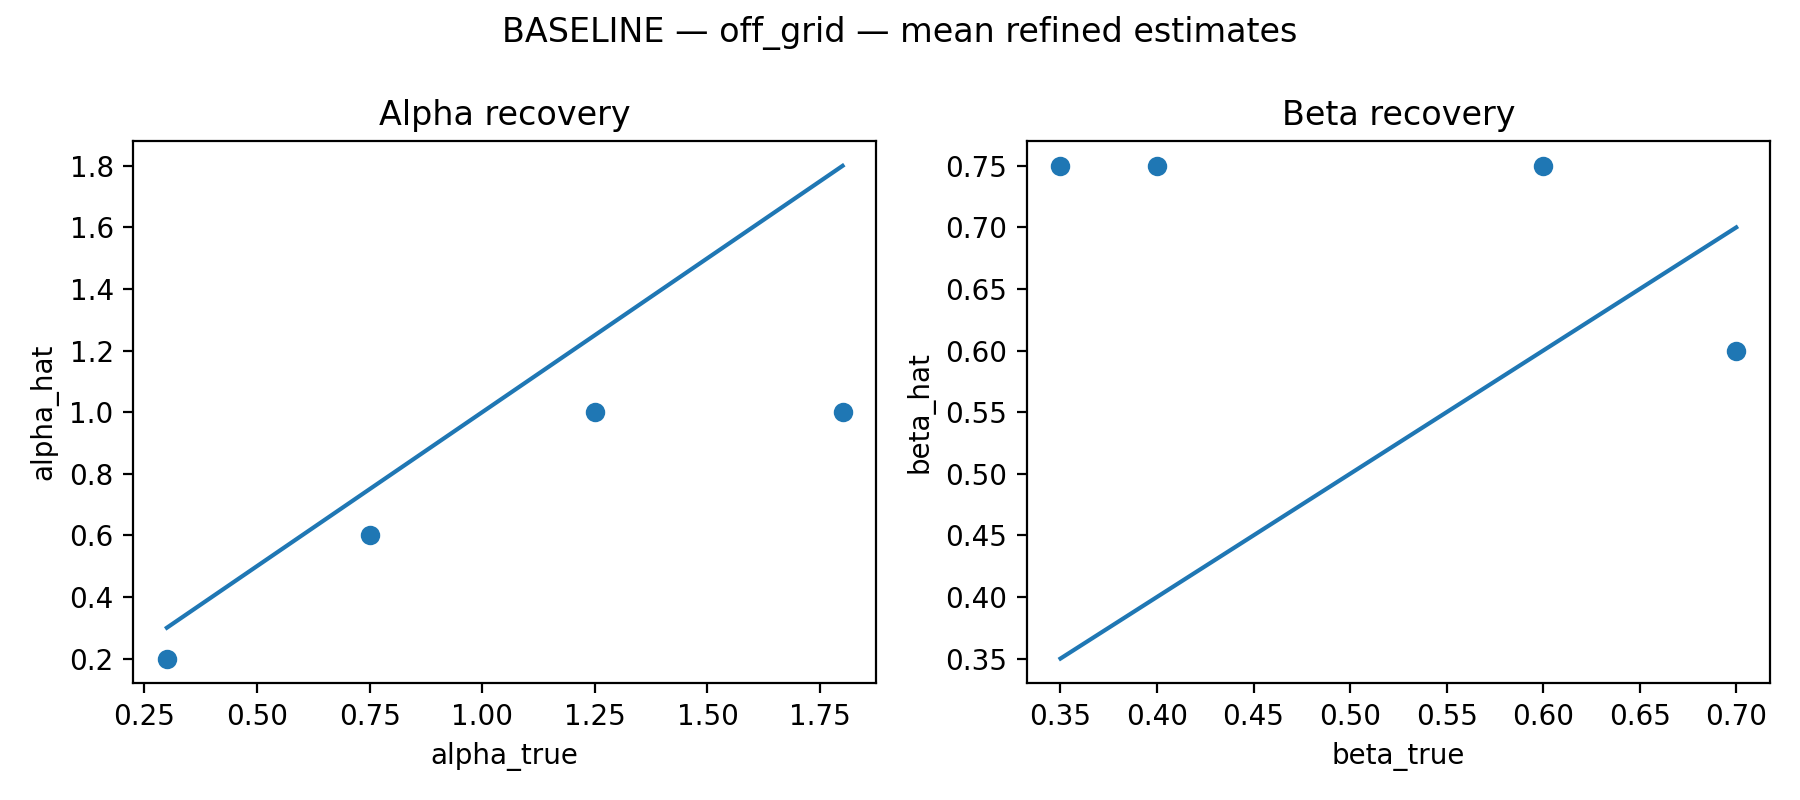

In [ ]:
# Display the 4 scatter plots here

from IPython.display import Image, display

for fn in [
    "recovery_scatter_on_grid_rl.png",
    "recovery_scatter_off_grid_rl.png",
    "recovery_scatter_on_grid_baseline.png",
    "recovery_scatter_off_grid_baseline.png",
]:
    display(Image(filename=os.path.join(OUTDIR, fn)))

## Outputs and paper mapping

When you run the notebook, it writes all artefacts to `outputs_draft5/`.

### Tables (CSV)
- `table_on_grid_by_seed.csv` and `table_off_grid_by_seed.csv`  
  Per‑seed parameter‑recovery results and loss diagnostics.
- `summary_on_grid.csv` and `summary_off_grid.csv`  
  Seed‑aggregated means and standard deviations (useful for the paper tables).

### Figures (PNG)
- `recovery_scatter_on_grid_rl.png`, `recovery_scatter_off_grid_rl.png`
- `recovery_scatter_on_grid_baseline.png`, `recovery_scatter_off_grid_baseline.png`

### Reproducibility notes
- The “observed” behaviour in Stage‑1 is generated synthetically using `TRUE_SOLVER` (default: `"rl"`).
- The fit target is controlled by `JOINT_FIT`:
  - `False`: fit on Ultimatum only; report Dictator as a cross‑task predictive check.
  - `True`: fit jointly on Ultimatum + Dictator moments.
